# Model Interpretability & Explainability
Techniques to understand and explain ML model predictions.
Prerequisites: `pip install numpy matplotlib scikit-learn pandas`

📺 **Video Lecture:** [https://youtu.be/lLWq7gd0w5g](https://youtu.be/lLWq7gd0w5g)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
np.random.seed(42)

## 1. Intrinsic vs Post-hoc Interpretability
- **Intrinsic**: model is interpretable by design (linear, decision tree)
- **Post-hoc**: explain a black-box model after training (SHAP, LIME)

In [3]:
# Generate synthetic data
X, y = make_classification(n_samples=500, n_features=6, n_informative=4,
                           n_redundant=1, random_state=42)
feature_names = ['Income', 'Age', 'Credit_Score', 'Debt_Ratio', 'Employment_Years', 'Num_Accounts']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
lr = LogisticRegression(max_iter=200).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

print(f'Logistic Regression accuracy: {lr.score(X_test, y_test):.3f}')
print(f'Random Forest accuracy: {rf.score(X_test, y_test):.3f}')

Logistic Regression accuracy: 0.750
Random Forest accuracy: 0.860


## 2. Feature Importance (Built-in)

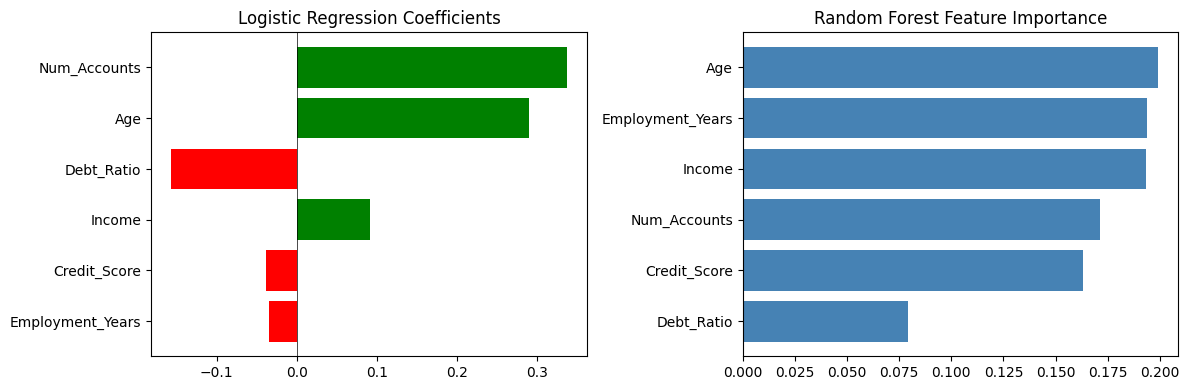

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression coefficients
coefs = lr.coef_[0]
sorted_idx = np.argsort(np.abs(coefs))
axes[0].barh([feature_names[i] for i in sorted_idx], coefs[sorted_idx],
             color=['red' if c < 0 else 'green' for c in coefs[sorted_idx]])
axes[0].set_title('Logistic Regression Coefficients')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Random Forest feature importance
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)
axes[1].barh([feature_names[i] for i in sorted_idx], importances[sorted_idx], color='steelblue')
axes[1].set_title('Random Forest Feature Importance')

plt.tight_layout(); plt.show()

## 3. Permutation Importance
Model-agnostic: shuffle one feature at a time and measure accuracy drop.

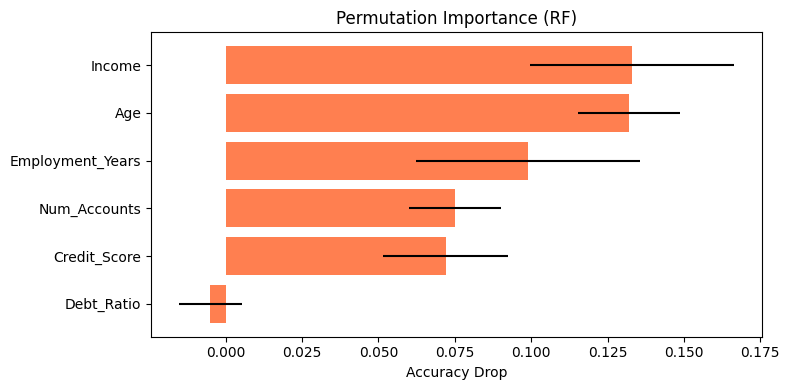

In [5]:
from sklearn.metrics import accuracy_score

def permutation_importance(model, X, y, n_repeats=10):
    baseline = accuracy_score(y, model.predict(X))
    importances = np.zeros((n_repeats, X.shape[1]))
    
    for r in range(n_repeats):
        for col in range(X.shape[1]):
            X_perm = X.copy()
            np.random.shuffle(X_perm[:, col])
            score = accuracy_score(y, model.predict(X_perm))
            importances[r, col] = baseline - score
    
    return importances.mean(axis=0), importances.std(axis=0)

mean_imp, std_imp = permutation_importance(rf, X_test, y_test)
sorted_idx = np.argsort(mean_imp)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([feature_names[i] for i in sorted_idx], mean_imp[sorted_idx],
        xerr=std_imp[sorted_idx], color='coral')
ax.set_title('Permutation Importance (RF)'); ax.set_xlabel('Accuracy Drop')
plt.tight_layout(); plt.show()

## 4. Partial Dependence (PDP)
Shows the marginal effect of a feature on predictions.

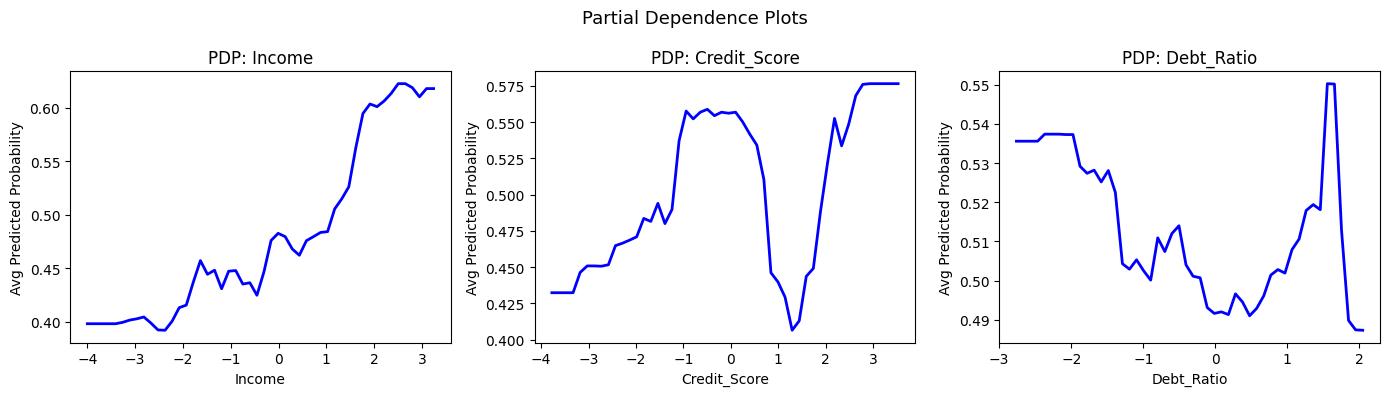

In [6]:
def partial_dependence(model, X, feature_idx, grid_points=50):
    x_range = np.linspace(X[:, feature_idx].min(), X[:, feature_idx].max(), grid_points)
    pd_values = []
    for val in x_range:
        X_mod = X.copy()
        X_mod[:, feature_idx] = val
        pred = model.predict_proba(X_mod)[:, 1].mean()
        pd_values.append(pred)
    return x_range, pd_values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat_idx in zip(axes, [0, 2, 3]):
    x_range, pd_vals = partial_dependence(rf, X_test, feat_idx)
    ax.plot(x_range, pd_vals, 'b-', linewidth=2)
    ax.set_xlabel(feature_names[feat_idx])
    ax.set_ylabel('Avg Predicted Probability')
    ax.set_title(f'PDP: {feature_names[feat_idx]}')
plt.suptitle('Partial Dependence Plots', fontsize=13)
plt.tight_layout(); plt.show()

## 5. LIME-Style Local Explanation
Explain individual predictions by fitting a local linear model.

Prediction: P(class=0)=0.210, P(class=1)=0.790


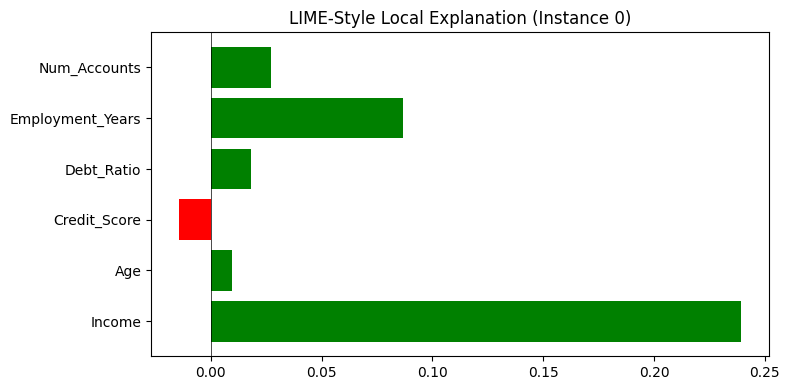

In [7]:
def lime_explain(model, instance, X_train, n_samples=500, noise_scale=0.5):
    """Simplified LIME: perturb around instance, fit local linear model."""
    # Generate perturbations around the instance
    perturbations = instance + np.random.randn(n_samples, len(instance)) * noise_scale
    predictions = model.predict_proba(perturbations)[:, 1]
    
    # Compute distances (weights)
    distances = np.sqrt(np.sum((perturbations - instance)**2, axis=1))
    weights = np.exp(-distances**2 / (2 * noise_scale**2))
    
    # Fit weighted linear model
    from sklearn.linear_model import Ridge
    local_model = Ridge(alpha=1.0)
    local_model.fit(perturbations, predictions, sample_weight=weights)
    
    return local_model.coef_

# Explain a single prediction
instance = X_test[0]
pred = rf.predict_proba(instance.reshape(1, -1))[0]
local_coefs = lime_explain(rf, instance, X_train)

print(f'Prediction: P(class=0)={pred[0]:.3f}, P(class=1)={pred[1]:.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if c > 0 else 'red' for c in local_coefs]
ax.barh(feature_names, local_coefs, color=colors)
ax.set_title('LIME-Style Local Explanation (Instance 0)')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

## 6. SHAP Values (Concept)
Shapley values from game theory: each feature's marginal contribution.

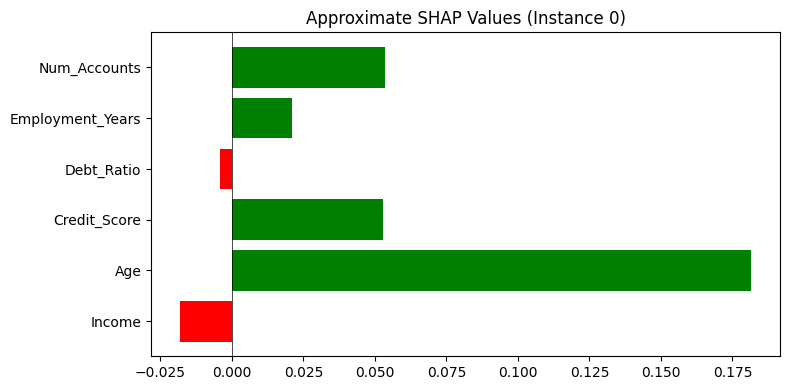

In [8]:
# Simplified SHAP-like computation for a small example
# For a proper implementation, use the `shap` library

from itertools import combinations

def simple_shapley(model, instance, X_background, feature_idx, n_bg=50):
    """Approximate Shapley value for one feature (brute-force for small feature sets)."""
    n_features = len(instance)
    other_features = [i for i in range(n_features) if i != feature_idx]
    bg = X_background[:n_bg]
    
    shapley_val = 0
    count = 0
    
    # Sample coalitions
    for size in range(len(other_features) + 1):
        for coalition in combinations(other_features, size):
            coalition = set(coalition)
            
            # With feature
            X_with = bg.copy()
            for f in coalition | {feature_idx}:
                X_with[:, f] = instance[f]
            pred_with = model.predict_proba(X_with)[:, 1].mean()
            
            # Without feature
            X_without = bg.copy()
            for f in coalition:
                X_without[:, f] = instance[f]
            pred_without = model.predict_proba(X_without)[:, 1].mean()
            
            shapley_val += pred_with - pred_without
            count += 1
    
    return shapley_val / count if count > 0 else 0

# Compute for all features (slow but correct for small problems)
shap_vals = [simple_shapley(rf, X_test[0], X_train, i) for i in range(X.shape[1])]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if v > 0 else 'red' for v in shap_vals]
ax.barh(feature_names, shap_vals, color=colors)
ax.set_title('Approximate SHAP Values (Instance 0)')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

## 7. Interview Takeaways
- **Intrinsic** (linear models, trees) vs **post-hoc** (SHAP, LIME) interpretability
- **Feature importance**: built-in (RF), permutation (model-agnostic)
- **SHAP**: theoretically grounded (Shapley values), global + local explanations
- **LIME**: local surrogate model, model-agnostic
- **PDP/ICE**: show feature effect on predictions
- Interpretability is crucial for regulated industries (finance, healthcare)
- There's often a tradeoff between accuracy and interpretability

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>